# sharpelab_nb Demo

Exercises the plotting functions against RPL_19 data.

In [ ]:
%matplotlib inline
import sys

sys.path.insert(0, "..")

from sharpelab_nb import (
    build_measurement_config,
    label_for_role,
)
from sharpelab_nb.plotting import (
    plot_sweep,
    plot_gatemap,
    plot_hysteresis,
    plot_raster_preview,
    plot_leakage,
)

## Setup

Define the mc and contact_pairs for the file range we're targeting.
Files 1541-1553 use mc_31 (field sweeps at various gate configurations).

In [2]:
file_path = "/home/zack/sharpelab/measureme-data/toploader/aaron/RPL_19/data"

# mc_31 from 20260217_measure.ipynb
mc_31 = {
    "sr830_1": "29-28",
    "sr830_2": "28-25",
    "sr830_3": "25-24",
    "sr830_4": "I_{30-21}",
    "sr830_5": "28-10",
    "sr830_6": "25-11.",
    "sr830_7": "24-13",
    "sr830_8": "13-14",
    "sr830_9": "14-15",
}

# Contact pairs matching the analysis notebook for this mc
cp_31 = {
    "curr": {"channels": [4]},
    "long1": {"channels": [1, 2]},
    "fakehall": {"channels": [3]},
    "realhall": {"channels": [5, 6]},
    "nl": {"channels": [7]},
}

contact_pairs = build_measurement_config(mc_31, cp_31)["contact_pairs"]
contact_pairs

{'curr': {'channels': [4], 'contacts': ['I_{30-21}']},
 'long1': {'channels': [1, 2], 'contacts': ['29-28', '28-25']},
 'fakehall': {'channels': [3], 'contacts': ['25-24']},
 'realhall': {'channels': [5, 6], 'contacts': ['28-10', '25-11.']},
 'nl': {'channels': [7], 'contacts': ['24-13']}}

## Type 2: 1D Line Sweep

Plot field sweeps with value + phase panels per channel.

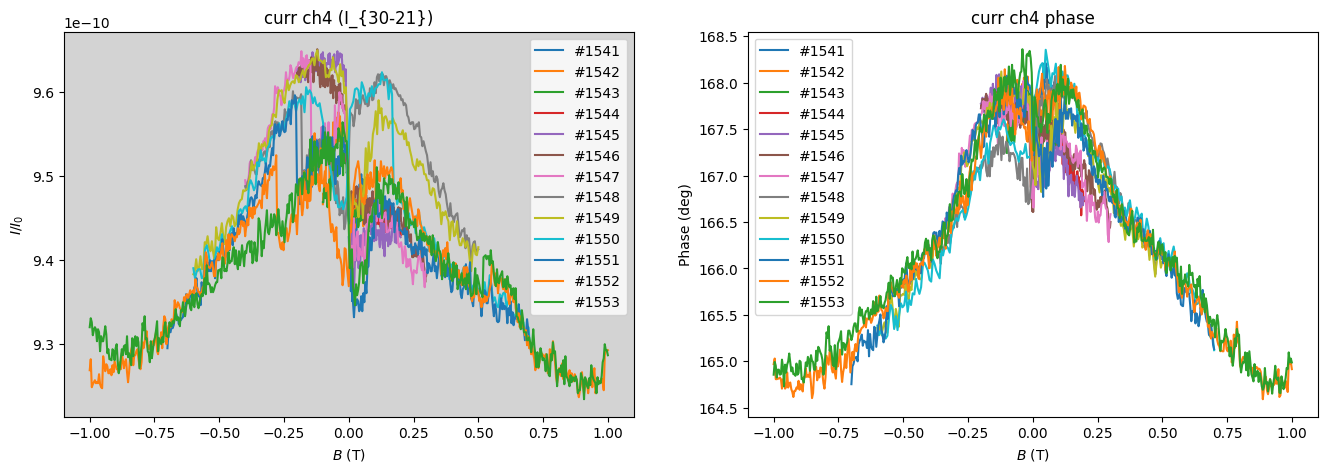

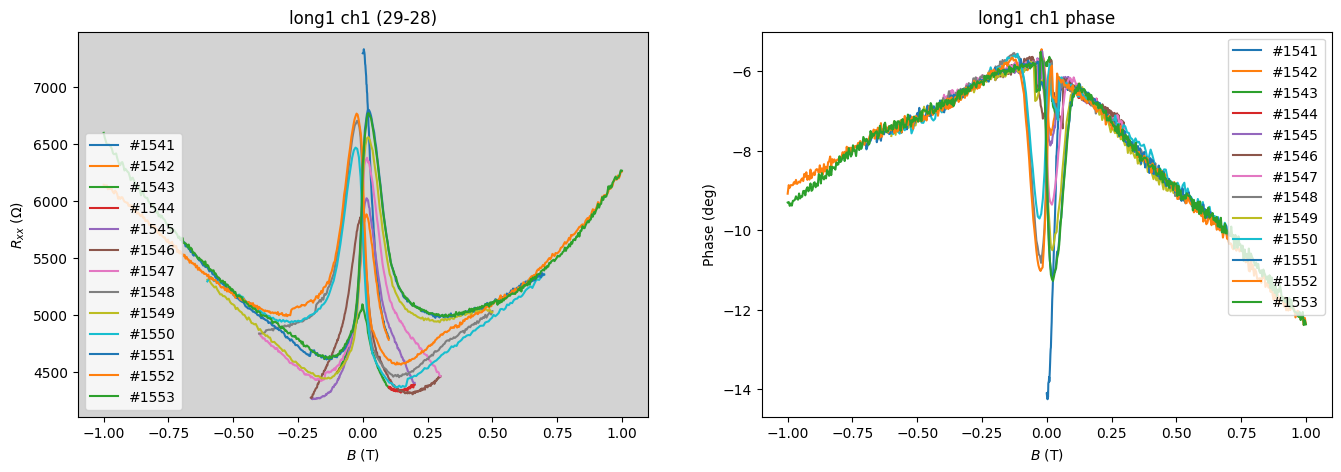

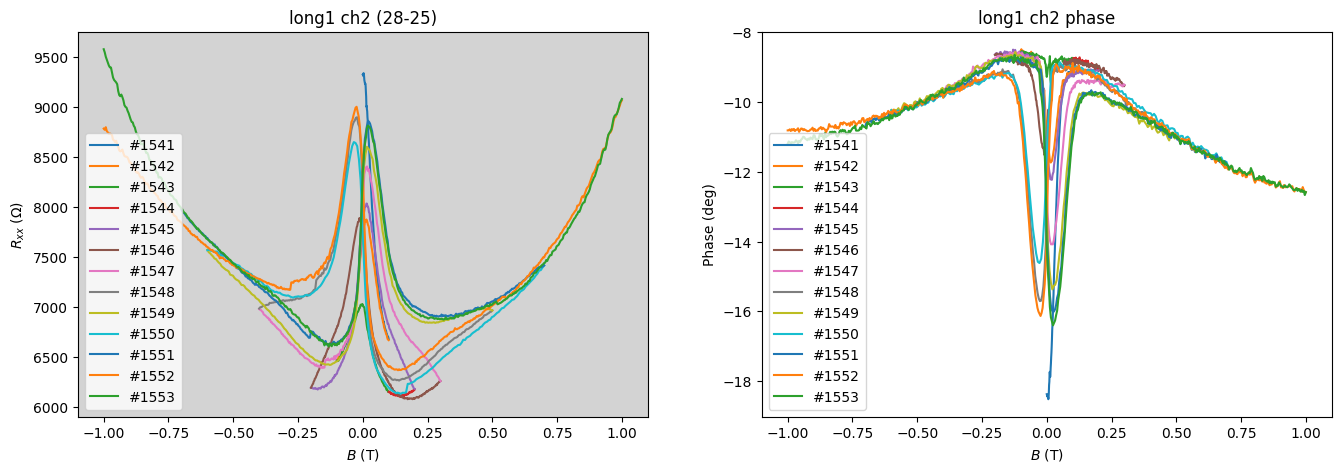

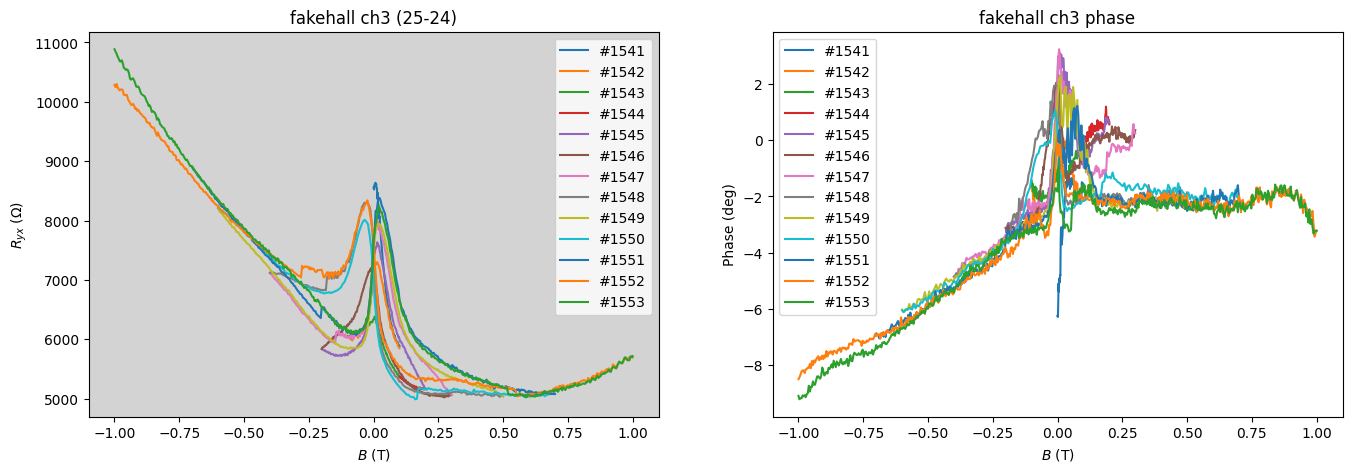

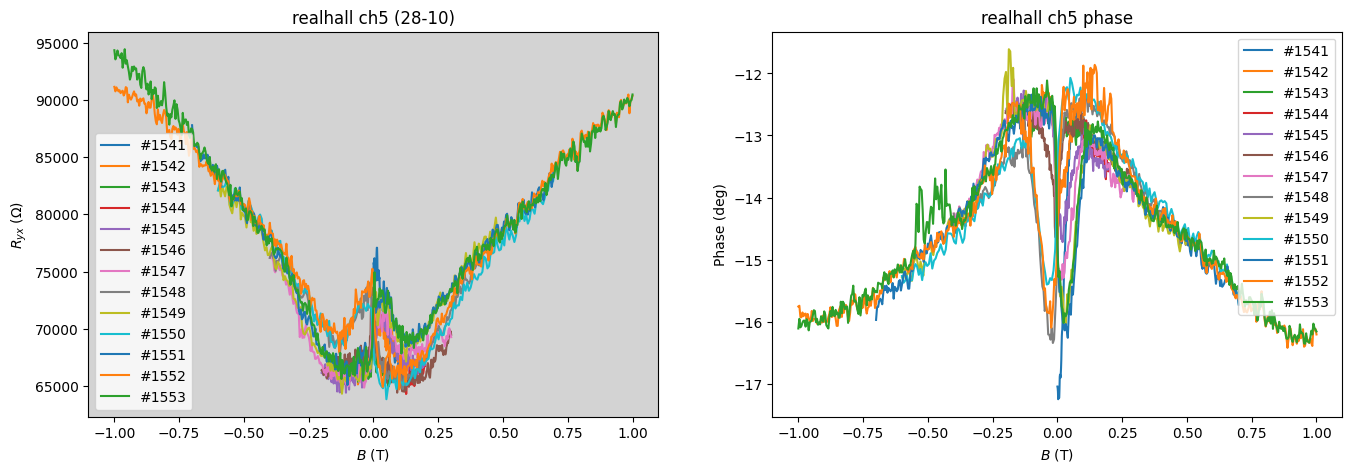

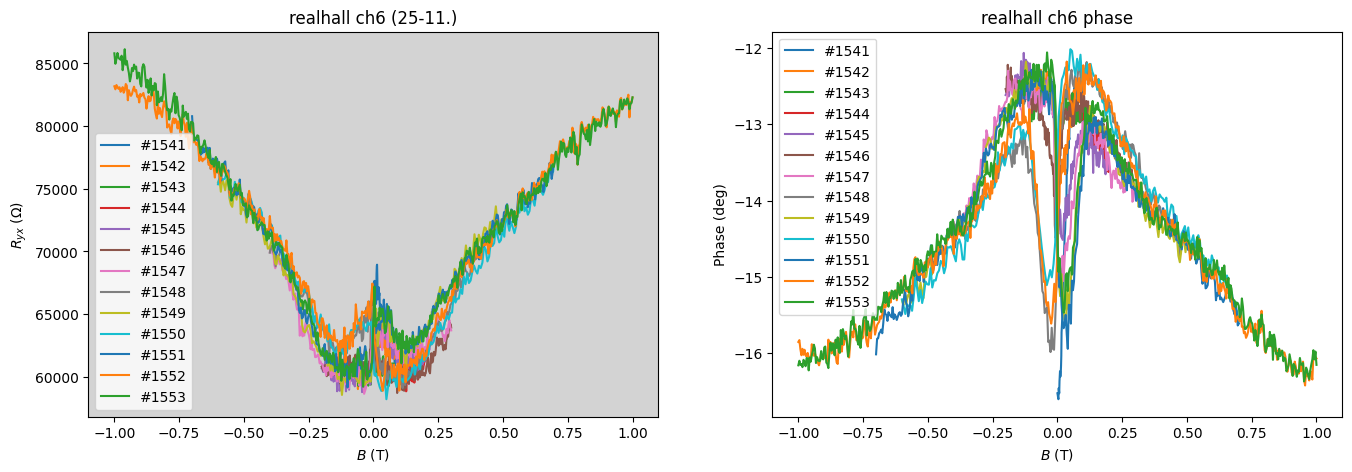

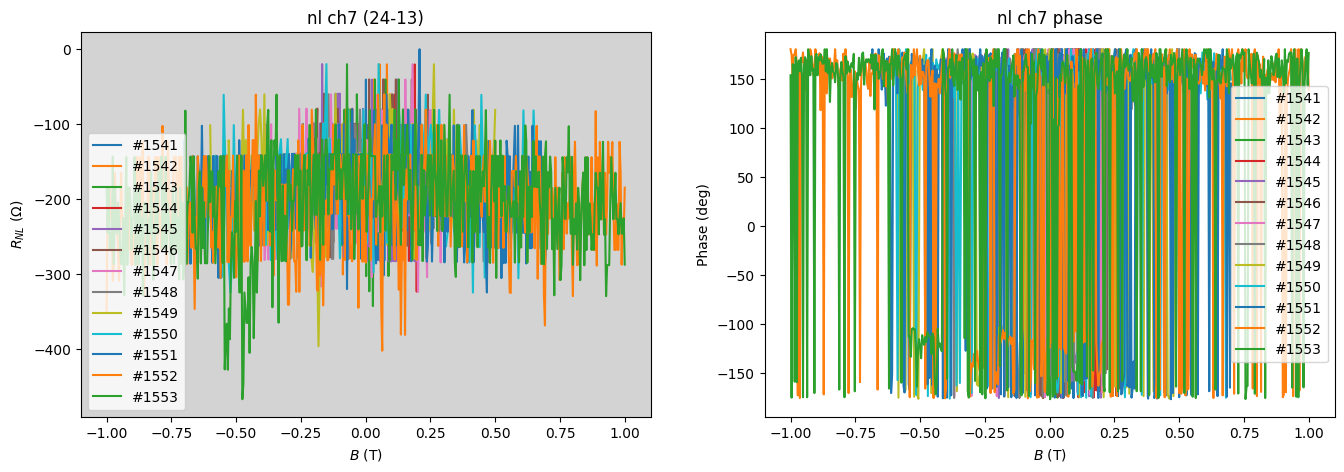

In [ ]:
files = list(range(1541, 1554))  # 1541-1553, matching the analysis notebook
result = plot_sweep(file_path, files)

## Post-hoc adjustments

The result object exposes axes for tweaking after creation.

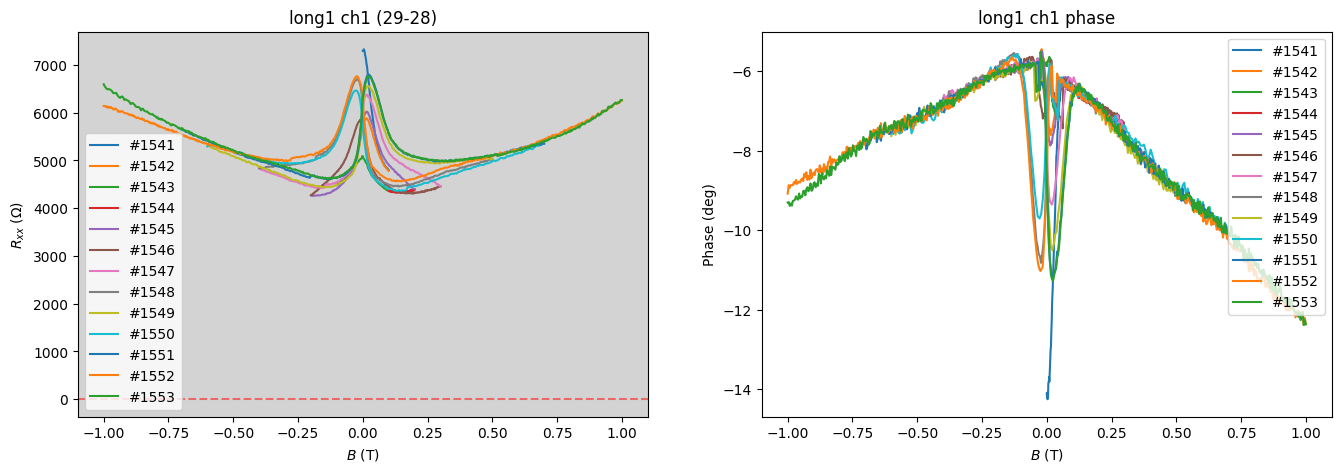

In [4]:
# Draw a horizontal line on the long1 ch1 value panel
result.ax("long1", 1).axhline(0, color="red", linestyle="--", alpha=0.5)
result.fig("long1", 1)

## Log scale variant

/home/zack/code/measureme/.venv/lib/python3.13/site-packages/IPython/core/events.py:96: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


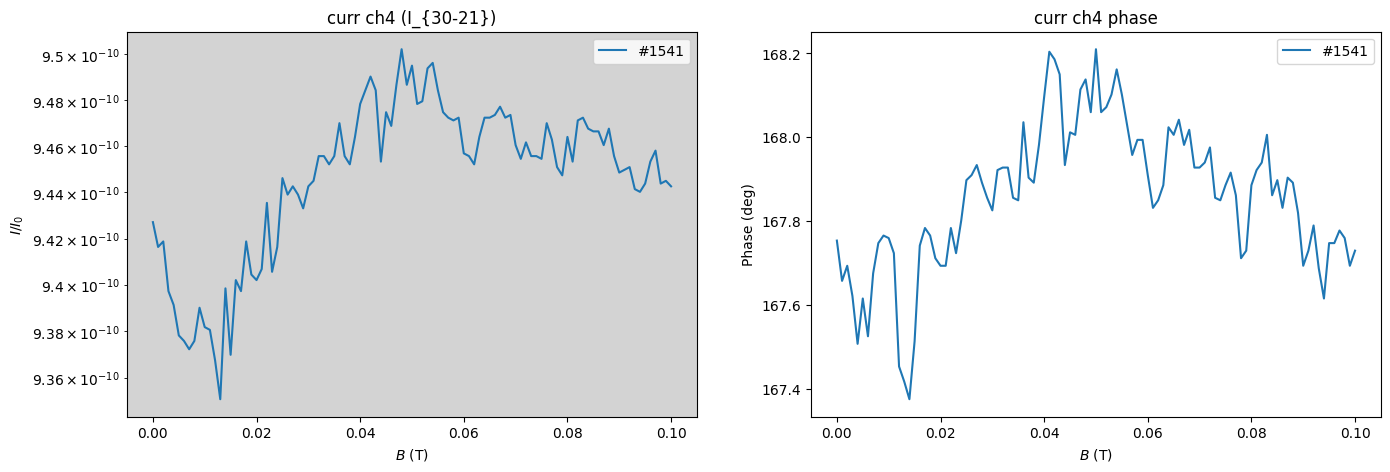

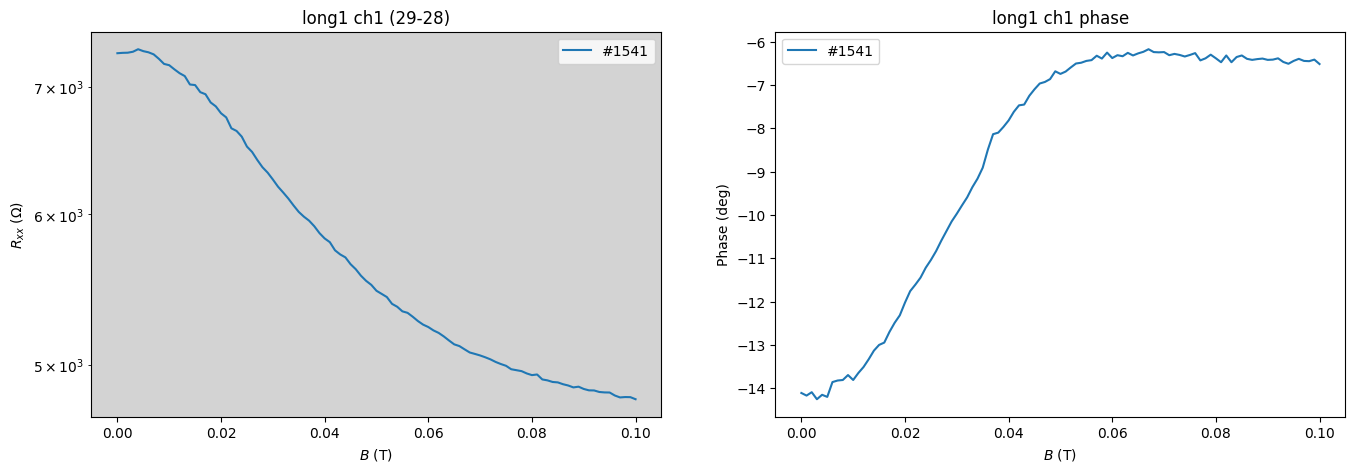

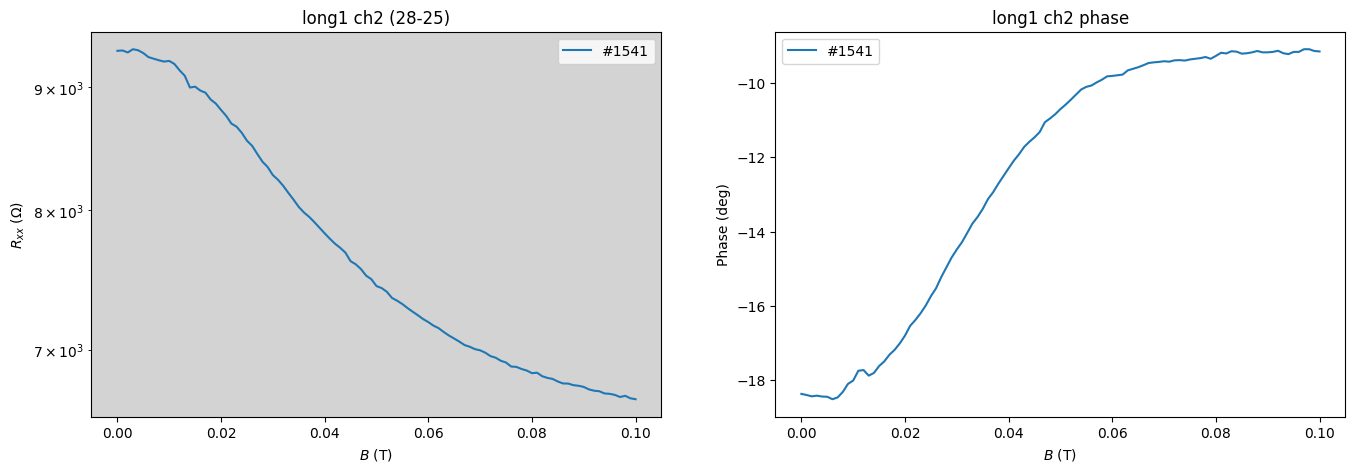

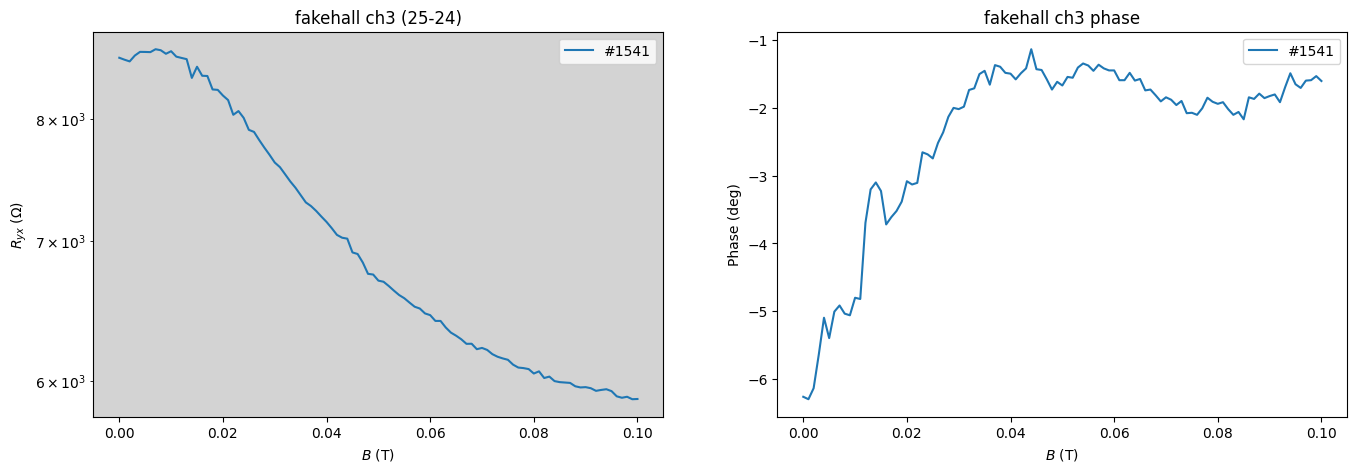

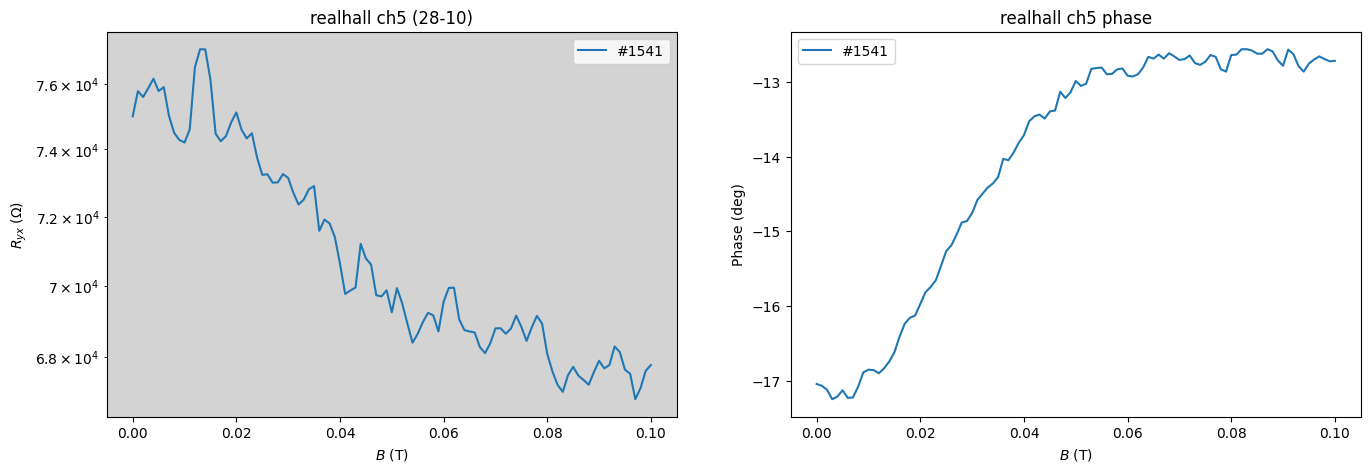

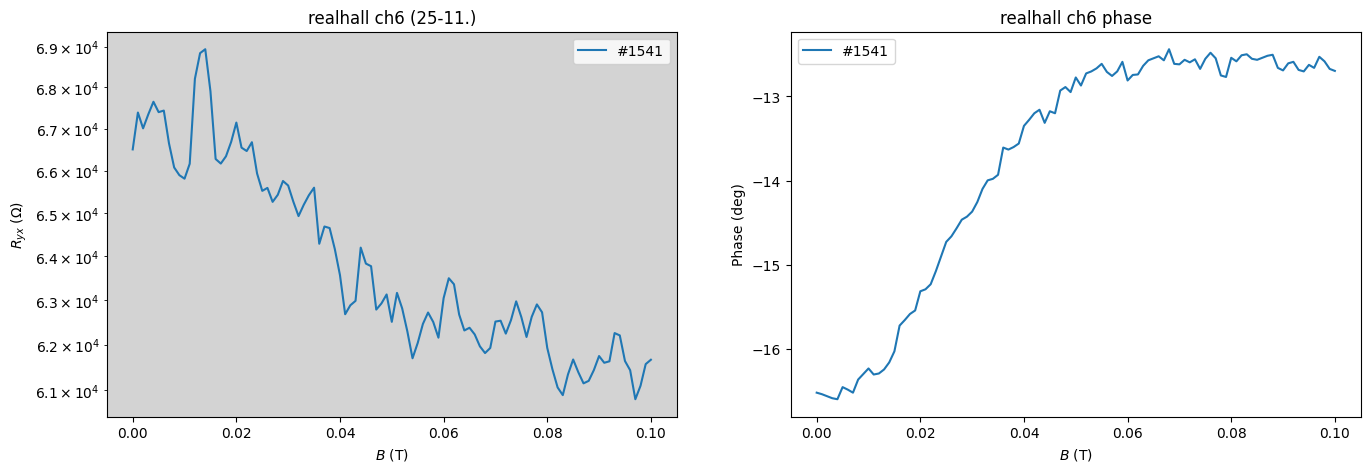

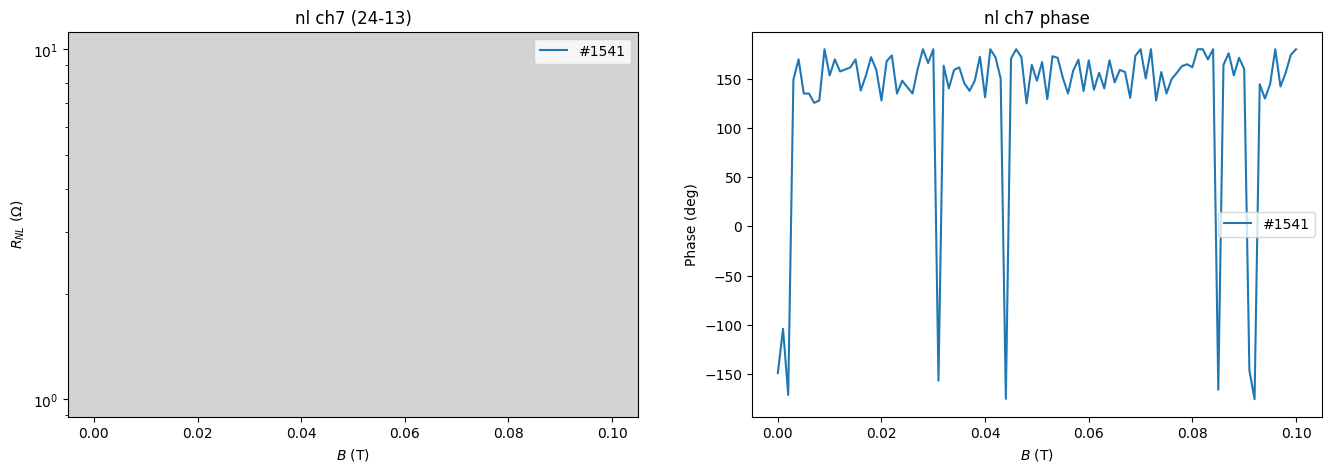

In [5]:
result_log = plot_sweep(file_path, [1541], contact_pairs=contact_pairs, log=True)

## Label derivation

In [6]:
for role in cp_31:
    print(f"{role:>12} -> {label_for_role(role)}")

        curr -> $I/I_0$
       long1 -> $R_{xx}$ ($\Omega$)
    fakehall -> $R_{yx}$ ($\Omega$)
    realhall -> $R_{yx}$ ($\Omega$)
          nl -> $R_{NL}$ ($\Omega$)


## Type 1: 2D Raster Gatemap

File 1266 is a complete 101×101 megasweep over k_tg_volt (slow) × k_bg_volt (fast).
Different wiring from mc_31, so we define a separate measurement config.

In [ ]:
mc_1266 = {
    "sr830_1": "29-28",
    "sr830_2": "28-25",
    "sr830_3": "25-24",
    "sr830_4": "I_{30-17}",
    "sr830_5": "13-14",
    "sr830_6": "10-11",
    "sr830_7": "11-13",
    "sr830_8": "14-15",
    "sr830_9": "24-22",
}

cp_1266 = {
    "curr": {"channels": [4]},
    "long1": {"channels": [1, 2]},
    "long2": {"channels": [3]},
    "hall": {"channels": [5, 6]},
    "nl": {"channels": [7]},
}

contact_pairs_1266 = build_measurement_config(mc_1266, cp_1266)["contact_pairs"]
contact_pairs_1266

### Basic gatemap (gate voltage axes)

In [ ]:
gm_result = plot_gatemap(file_path, 1266, contact_pairs=contact_pairs_1266)

### n/D conversion

Convert gate voltages to carrier density and displacement field.

In [ ]:
gm_result_nD = plot_gatemap(file_path, 1266, contact_pairs=contact_pairs_1266, nD=True)

### Post-hoc adjustments

Change colormap and normalization after plotting.

In [ ]:
from matplotlib.colors import SymLogNorm

gm_result.mesh("long1", 1).set_norm(SymLogNorm(linthresh=10, vmin=-3e4, vmax=3e4))
gm_result.mesh("long1", 1).set_cmap("RdBu_r")
gm_result.fig("long1", 1)

## Type 3: Hysteresis Check

Files 1541/1542 are a forward/backward magnet field sweep pair.

In [ ]:
hyst_result = plot_hysteresis(file_path, 1541, contact_pairs=contact_pairs)

## Type 4: Raster Preview

Preview the raster sweep path in (n, D) space with corresponding gate voltages.

In [ ]:
import numpy as np

# Diamond in (n, D) space
vertices = np.array([[0, -0.4], [3, 0], [0, 0.4], [-3, 0], [0, -0.4]])
fig = plot_raster_preview(vertices, nx=51, ny=51, nD=True)

## Type 5: Leakage Check

Gate leakage current vs swept parameter for the first few files.

In [ ]:
fig, ax = plot_leakage(file_path, [0, 1, 2], gate="tg")